In [4]:
import numpy as np
import json
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, Optional, Union
import pandas as pd

def load_intervention_results(
    intervention_var: str,
    outcome_var: str,
    model_type: str,
    save_dir: str = 'intervention_results'
) -> Dict:
    """
    Load previously saved intervention results for a single intervention.
    
    Args:
        intervention_var: Name of intervention variable
        outcome_var: Name of outcome variable
        model_type: 'kg', 'no_graph_random', or 'no_graph_gt_order'
        save_dir: Directory where results are saved
    
    Returns:
        Dictionary with ate_selected, ate_gt arrays and metadata
    """
    load_path = Path(save_dir) / model_type
    filename = f"{intervention_var}_to_{outcome_var}".replace(' ', '_')
    
    npz_path = load_path / f"{filename}.npz"
    meta_path = load_path / f"{filename}_metadata.json"
    
    if not npz_path.exists():
        raise FileNotFoundError(f"No intervention results found at {npz_path}")
    
    # Load numpy arrays
    data = np.load(npz_path)
    
    # Load metadata
    metadata = {}
    if meta_path.exists():
        with open(meta_path, 'r') as f:
            metadata = json.load(f)
    
    return {
        'ate_selected': data['ate_selected'],
        'ate_gt': data['ate_gt'],
        'valid_models': metadata.get('valid_models', len(data['ate_selected'])),
        'skipped_models': metadata.get('skipped_models', 0),
        'intervention_var': metadata.get('intervention_var', intervention_var),
        'outcome_var': metadata.get('outcome_var', outcome_var),
        'intervention_values': metadata.get('intervention_values', []),
        'variable_type': metadata.get('variable_type', ''),
        'metadata': metadata
    }


def load_all_interventions_batch(
    model_type: str,
    save_dir: str = 'intervention_results'
) -> Dict[str, Dict[str, Dict]]:
    """
    Load ALL saved intervention results for a model type.
    
    Args:
        model_type: 'kg', 'no_graph_random', or 'no_graph_gt_order'
        save_dir: Directory where results are saved
    
    Returns:
        Nested dictionary: {target_var: {intervention_var: results_dict}}
    """
    load_path = Path(save_dir) / model_type
    
    if not load_path.exists():
        raise FileNotFoundError(f"No results directory found at {load_path}")
    
    all_results = {}
    loaded_count = 0
    failed_count = 0
    
    # Find all .npz files
    npz_files = list(load_path.glob("*.npz"))
    
    print(f"\nLoading {len(npz_files)} intervention results for '{model_type}'...")
    
    for npz_file in npz_files:
        try:
            # Parse filename: "intervention_var_to_outcome_var.npz"
            filename = npz_file.stem
            parts = filename.split('_to_')
            
            if len(parts) != 2:
                continue
                
            intervention_var = parts[0].replace('_', ' ')
            outcome_var = parts[1].replace('_', ' ')
            
            # Load results
            result = load_intervention_results(
                intervention_var=intervention_var,
                outcome_var=outcome_var,
                model_type=model_type,
                save_dir=save_dir
            )
            
            # Organize by target (outcome) variable
            if outcome_var not in all_results:
                all_results[outcome_var] = {}
            
            all_results[outcome_var][intervention_var] = result
            loaded_count += 1
            
        except Exception as e:
            print(f"✗ Failed to load {npz_file.name}: {e}")
            failed_count += 1
    
    print(f"✓ Loaded {loaded_count} interventions, {failed_count} failed")
    
    return all_results


def create_summary_dataframe(
    all_results: Dict[str, Dict[str, Dict]],
    model_type: str
) -> pd.DataFrame:
    """
    Create a summary DataFrame from loaded intervention results.
    
    Args:
        all_results: Dictionary from load_all_interventions_batch()
        model_type: Model type for labeling
    
    Returns:
        DataFrame with summary statistics for all interventions
    """
    rows = []
    
    for target_var, interventions in all_results.items():
        for intervention_var, results in interventions.items():
            ate_selected = results['ate_selected']
            ate_gt = results['ate_gt']
            
            rows.append({
                'Model Type': model_type,
                'Target Variable': target_var,
                'Intervention Variable': intervention_var,
                'Variable Type': results.get('variable_type', ''),
                'Intervention Low': results['intervention_values'][0] if results['intervention_values'] else None,
                'Intervention High': results['intervention_values'][1] if len(results['intervention_values']) > 1 else None,
                'Mean ATE (Selected)': ate_selected.mean() if len(ate_selected) > 0 else np.nan,
                'Std ATE (Selected)': ate_selected.std() if len(ate_selected) > 0 else np.nan,
                'Mean ATE (GT)': ate_gt.mean() if len(ate_gt) > 0 else np.nan,
                'Std ATE (GT)': ate_gt.std() if len(ate_gt) > 0 else np.nan,
                'ATE Difference': abs(ate_selected.mean() - ate_gt.mean()) if len(ate_selected) > 0 and len(ate_gt) > 0 else np.nan,
                'Valid Models': results['valid_models'],
                'Skipped Models': results['skipped_models']
            })
    
    return pd.DataFrame(rows)


# USAGE EXAMPLE:

# 1. Load all KG interventions
all_kg_results = load_all_interventions_batch(
    model_type='kg',
    save_dir='intervention_results'
)
all

# 2. Load all no-graph random order interventions
all_no_graph_random_results = load_all_interventions_batch(
    model_type='no_graph_random',
    save_dir='intervention_results'
)

# 3. Load all no-graph GT order interventions
all_no_graph_gt_order_results = load_all_interventions_batch(
    model_type='no_graph_gt_order',
    save_dir='intervention_results'
)

# # 4. Create summary DataFrames
df_kg = create_summary_dataframe(all_kg_results, 'Knowledge Graph')
df_kg
df_no_graph_random = create_summary_dataframe(all_no_graph_random_results, 'No-Graph Random')
df_no_graph_gt_order = create_summary_dataframe(all_no_graph_gt_order_results, 'No-Graph GT Order')



Loading 42 intervention results for 'kg'...
✓ Loaded 42 interventions, 0 failed

Loading 42 intervention results for 'no_graph_random'...
✓ Loaded 42 interventions, 0 failed

Loading 42 intervention results for 'no_graph_gt_order'...
✓ Loaded 42 interventions, 0 failed


In [29]:
def interval_iou(y_lo, y_hi, l, u):
    """
    Computes intersection-over-union (IoU) between two 1D intervals:
    the model interval [l, u] and the ground-truth interval [y_lo, y_hi].
    """
    a1, b1 = float(l), float(u)
    a2, b2 = float(y_lo), float(y_hi)
 
    if a1 > b1:
        a1, b1 = b1, a1
    if a2 > b2:
        a2, b2 = b2, a2
 
    intersection = max(0.0, min(b1, b2) - max(a1, a2))
    union = max(b1, b2) - min(a1, a2)
 
    if union == 0.0:
        return 1.0 if intersection == 0.0 else 0.0
 
    return intersection / union


def compute_interval_iou(ate_selected, ate_gt, confidence_level=0.95):
    """
    Compute 95% confidence intervals and IoU metric.
    """
    alpha = 1 - confidence_level
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    # Estimated interval
    l_e = np.percentile(ate_selected, lower_percentile)
    u_e = np.percentile(ate_selected, upper_percentile)
    
    # Ground truth interval
    l_g = np.percentile(ate_gt, lower_percentile)
    u_g = np.percentile(ate_gt, upper_percentile)
    
    # Compute IoU
    iou = interval_iou(l_g, u_g, l_e, u_e)
    
    return iou


def add_iou_to_results(all_results, model_type):
    """
    Calculate IoU for all interventions and return summary.
    """
    ious = []
    
    for target_var, interventions in all_results.items():
        for intervention_var, results in interventions.items():
            iou = compute_interval_iou(results['ate_selected'], results['ate_gt'])
            ious.append(iou)
    
    return {
        'model_type': model_type,
        'mean_iou': np.mean(ious),
        'std_iou': np.std(ious),
        'median_iou': np.median(ious),
        'min_iou': np.min(ious),
        'max_iou': np.max(ious)
    }


# Calcular IoU para cada tipo de modelo
iou_kg = add_iou_to_results(all_kg_results, 'Estimated-Graph Models')
iou_no_graph_random = add_iou_to_results(all_no_graph_random_results, 'No-Graph Random Models')
iou_no_graph_gt = add_iou_to_results(all_no_graph_gt_order_results, 'No-Graph GT Order Models')

# Comparar
comparison_df = pd.DataFrame([iou_kg, iou_no_graph_random, iou_no_graph_gt])
comparison_df

,model_type,mean_iou,std_iou,median_iou,min_iou,max_iou
0,Estimated-Graph Models,0.723161,0.263947,0.824754,0.000000,0.998004
1,No-Graph Random Models,0.300823,0.179330,0.252751,0.057677,0.889733
2,No-Graph GT Order Models,0.711698,0.271725,0.814979,0.000000,0.996317


In [12]:
def compare_iou_by_intervention(all_kg, all_random, all_gt):
    """
    Compare IoU scores across models for each intervention-target pair.
    """
    comparison_data = []
    
    # Get all target variables (should be same across models)
    for target_var in all_kg.keys():
        for intervention_var in all_kg[target_var].keys():
            # Compute IoU for each model
            iou_kg = compute_interval_iou(
                all_kg[target_var][intervention_var]['ate_selected'],
                all_kg[target_var][intervention_var]['ate_gt']
            )
            
            iou_random = compute_interval_iou(
                all_random[target_var][intervention_var]['ate_selected'],
                all_random[target_var][intervention_var]['ate_gt']
            )
            
            iou_gt = compute_interval_iou(
                all_gt[target_var][intervention_var]['ate_selected'],
                all_gt[target_var][intervention_var]['ate_gt']
            )
            
            comparison_data.append({
                'Target': target_var,
                'Intervention': intervention_var,
                'IoU_KG': iou_kg,
                'IoU_Random': iou_random,
                'IoU_GT_Order': iou_gt
            })
    
    df = pd.DataFrame(comparison_data)
    
    return df

detailed_comparison = compare_iou_by_intervention(
    all_kg_results, 
    all_no_graph_random_results, 
    all_no_graph_gt_order_results
)

#detailed_comparison.to_csv('iou_detailed_comparison.csv', index=False)

detailed_comparison

,Target,Intervention,IoU_KG,IoU_Random,IoU_GT_Order
0,systolic pressure,cardiac ischemia,0.927878,0.242195,0.000000
1,systolic pressure,major acute cardiovascular event,0.909732,0.180610,0.872867
2,systolic pressure,age,0.886569,0.170891,0.847146
3,systolic pressure,diabetes mellitus,0.127646,0.172955,0.000000
4,systolic pressure,diastolic pressure,0.000000,0.099074,0.816338
5,systolic pressure,bmi,0.769987,0.307315,0.752345
6,diastolic pressure,age,0.658437,0.129083,0.813619
7,diastolic pressure,systolic pressure,0.822175,0.113334,0.847393
8,diastolic pressure,diabetes mellitus,0.665974,0.283652,0.653246
9,diastolic pressure,bmi,0.823625,0.196824,0.936957


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_iou_comparison(df_comparison, output_filename='iou_by_target_variable_comparison.png'):
    """
    Create IoU comparison boxplots for different models.
    
    Parameters:
    df_comparison : pandas.DataFrame
        DataFrame with columns: Target, Intervention, IoU_KG, IoU_Random, IoU_GT_Order
    output_filename : str, optional
        Filename for saving the plot
    
    Returns:
    summary_stats : pandas.DataFrame
        Summary statistics grouped by Target Variable and Model
    """
    sns.set_theme(style="whitegrid")
    
    # Reshape data for plotting
    iou_data = []
    for _, row in df_comparison.iterrows():
        iou_data.append({
            'Target Variable': row['Target'],
            'Intervention Variable': row['Intervention'],
            'Model': 'Estimated-Graph Models',
            'IoU': row['IoU_KG']
        })
        iou_data.append({
            'Target Variable': row['Target'],
            'Intervention Variable': row['Intervention'],
            'Model': 'No-Graph GT Order Models',
            'IoU': row['IoU_GT_Order']
        })
        iou_data.append({
            'Target Variable': row['Target'],
            'Intervention Variable': row['Intervention'],
            'Model': 'No-Graph Random Models',
            'IoU': row['IoU_Random']
        })
    
    df_iou_long = pd.DataFrame(iou_data)
    
    # Academic colors - reordered to match new order
    academic_colors = ['#1f77b4', '#eaa466', '#D9D9D9']  # Blue, Orange, Light Gray
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Set order explicitly
    model_order = ['Estimated-Graph Models', 'No-Graph GT Order Models', 'No-Graph Random Models']
    
    sns.boxplot(
        data=df_iou_long,
        x='Target Variable',
        y='IoU',
        hue='Model',
        hue_order=model_order,
        palette=academic_colors,
        ax=ax,
        showfliers=True,
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    
    ax.set_title('IoU by Target Variable', fontsize=14, fontweight='bold')
    ax.set_xlabel('Target Variable', fontsize=12)
    ax.set_ylabel('IoU Score', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower right', title='Model')
    
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calculate summary statistics
    summary_stats = df_iou_long.groupby(['Target Variable', 'Model'])['IoU'].agg([
        'mean', 'std', 'median', 'min', 'max'
    ])
    print("\nIoU Statistics by Target Variable:")
    print(summary_stats)
    
    return summary_stats


def plot_single_target_iou_bars(df_comparison, target_var, output_filename=None):
    """
    Create bar plots for IoU scores for a single target variable.
    """
    sns.set_theme(style="whitegrid")
    
    df_filtered = df_comparison[df_comparison['Target'] == target_var].copy()
    
    # Reshape data - reordered
    iou_data = []
    for _, row in df_filtered.iterrows():
        iou_data.append({
            'Intervention Variable': row['Intervention'],
            'Model': 'Estimated-Graph Models',
            'IoU': row['IoU_KG']
        })
        iou_data.append({
            'Intervention Variable': row['Intervention'],
            'Model': 'No-Graph GT Order Models',
            'IoU': row['IoU_GT_Order']
        })
        iou_data.append({
            'Intervention Variable': row['Intervention'],
            'Model': 'No-Graph Random Models',
            'IoU': row['IoU_Random']
        })
    
    df_iou_bars = pd.DataFrame(iou_data)
    
    academic_colors = ['#1f77b4', '#eaa466', '#D9D9D9']
    model_order = ['Estimated-Graph Models', 'No-Graph GT Order Models', 'No-Graph Random Models']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'IoU for Target: {target_var}', fontsize=16, fontweight='bold', y=0.98)
    
    sns.barplot(
        data=df_iou_bars,
        x='Intervention Variable',
        y='IoU',
        hue='Model',
        hue_order=model_order,
        palette=academic_colors,
        ax=ax
    )
    
    ax.set_xlabel('Intervention Variable', fontsize=12)
    ax.set_ylabel('IoU Score', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower right', title='Model', fontsize=10)
    
    plt.tight_layout()
    
    if output_filename:
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return df_iou_bars


#     # Calculate summary statistics
#     summary_stats = df_iou_long.groupby(['Target Variable', 'Model'])['IoU'].agg([
#         'mean', 'std', 'median', 'min', 'max'
#     ])
#     print("\nIoU Statistics by Target Variable:")
#     print(summary_stats)
    
#     return summary_stats


def plot_single_target_iou_bars(df_comparison, target_var, output_filename=None):
    """
    Create bar plots for IoU scores for a single target variable.
    
    Parameters:
    df_comparison : pandas.DataFrame
        DataFrame with columns: Target, Intervention, IoU_KG, IoU_Random, IoU_GT_Order
    target_var : str
        Target variable to plot
    output_filename : str, optional
        Filename for saving the plot
    """
    sns.set_theme(style="whitegrid")
    
    # Filter by target variable
    df_filtered = df_comparison[df_comparison['Target'] == target_var].copy()
    
    # Reshape data
    iou_data = []
    for _, row in df_filtered.iterrows():
        iou_data.append({
            'Intervention Variable': row['Intervention'],
            'Model': 'Estimated-Graph Models',
            'IoU': row['IoU_KG']
        })
        iou_data.append({
            'Intervention Variable': row['Intervention'],
            'Model': 'No-Graph Random Models',
            'IoU': row['IoU_Random']
        })
        iou_data.append({
            'Intervention Variable': row['Intervention'],
            'Model': 'No-Graph GT Order Models',
            'IoU': row['IoU_GT_Order']
        })
    
    df_iou_bars = pd.DataFrame(iou_data)
    
    academic_colors = ['#1f77b4', '#D9D9D9', '#eaa466']
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'IoU for Target: {target_var}', fontsize=16, fontweight='bold', y=0.98)
    
    sns.barplot(
        data=df_iou_bars,
        x='Intervention Variable',
        y='IoU',
        hue='Model',
        palette=academic_colors,
        ax=ax
    )
    
    ax.set_xlabel('Intervention Variable', fontsize=12)
    ax.set_ylabel('IoU Score', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower right', title='Model', fontsize=10)
    
    plt.tight_layout()
    
    if output_filename:
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return df_iou_bars



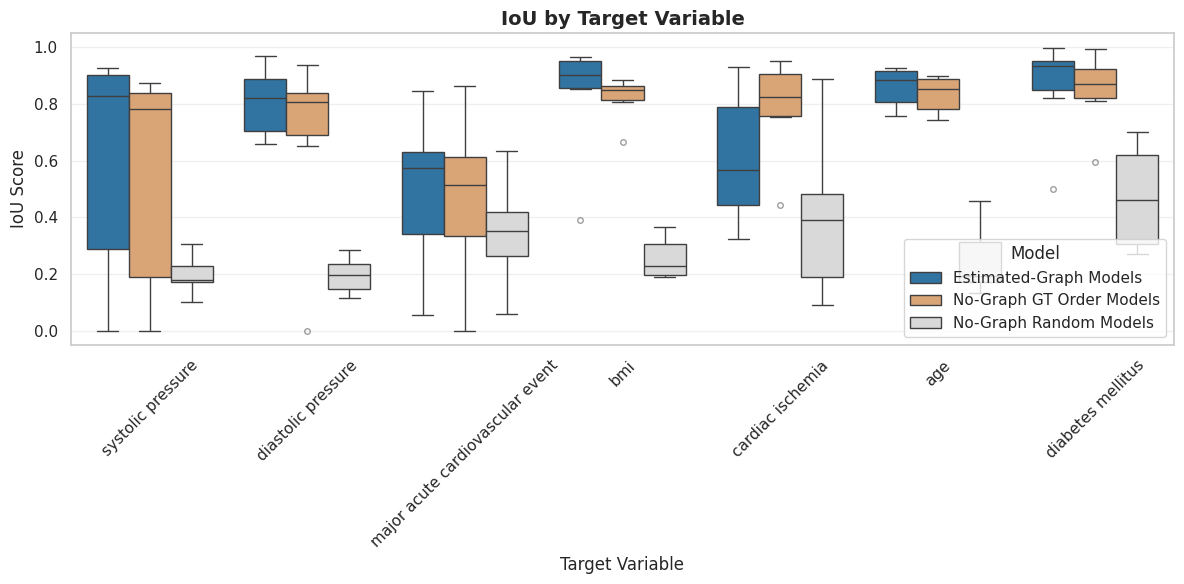


IoU Statistics by Target Variable:
                                                               mean       std  \
Target Variable                  Model                                          
age                              Estimated-Graph Models    0.861142  0.072121   
                                 No-Graph GT Order Models  0.835028  0.067452   
                                 No-Graph Random Models    0.248046  0.126705   
bmi                              Estimated-Graph Models    0.828529  0.220265   
                                 No-Graph GT Order Models  0.820822  0.080173   
                                 No-Graph Random Models    0.254160  0.074280   
cardiac ischemia                 Estimated-Graph Models    0.608989  0.240549   
                                 No-Graph GT Order Models  0.786783  0.185168   
                                 No-Graph Random Models    0.398771  0.289674   
diabetes mellitus                Estimated-Graph Models    0.857753  0.18

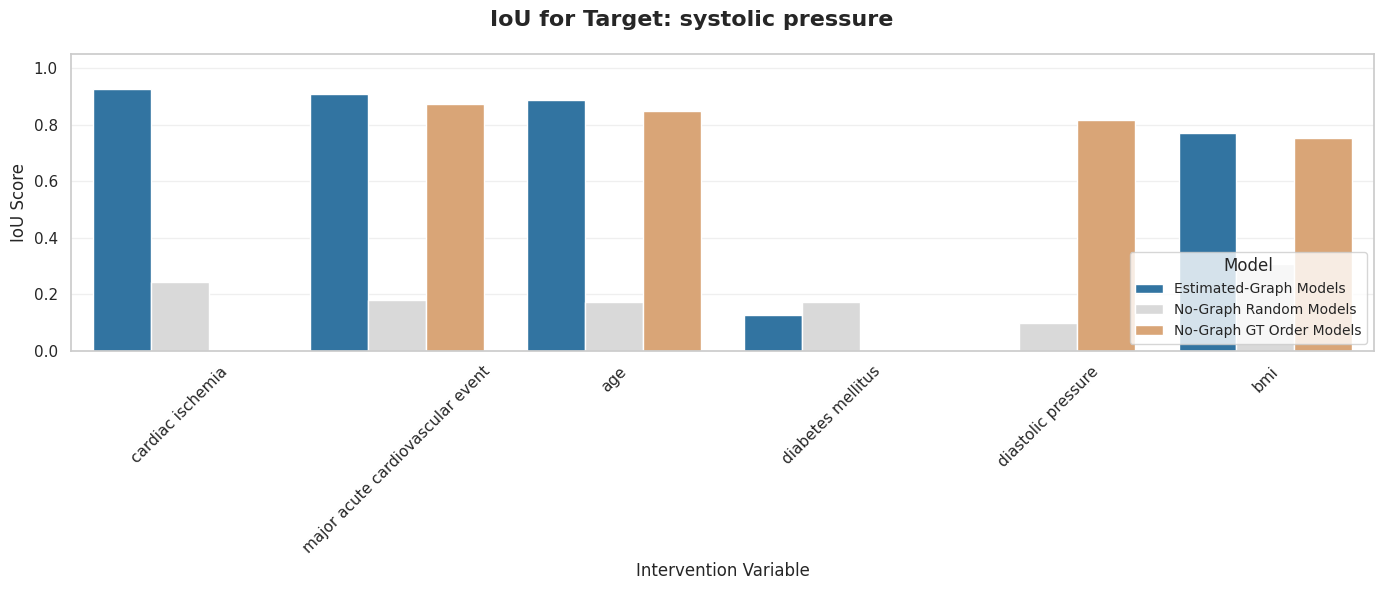

In [ ]:
summary_stats = plot_iou_comparison(detailed_comparison, 'iou_comparison.png')

target_variable = 'systolic pressure'
iou_bars = plot_single_target_iou_bars(
    detailed_comparison, 
    target_var=target_variable,
    output_filename=f'iou_{target_variable.replace(" ", "_")}.png'
)